# 01 Phase 1A — Price-Shape Only Quantization

이 notebook은 **Phase 1A — Price-Shape Only Quantization**의 재현 가능한 본 실험 노트입니다.

핵심 질문:

> 다양한 종목에서 반복적으로 나타나는 candle price-shape를 같은 discrete token으로 묶을 수 있는가?

실험 원칙:

- **single market × multiple symbols × single timeframe** 데이터셋을 사용합니다.
- feature는 순수 price-shape만 사용합니다.
- `volume_state`, `range_return`, raw OHLC scale, future return, trading label은 사용하지 않습니다.
- VQ-VAE 결과를 **scikit-learn KMeans baseline**과 비교합니다.
- 전체 metric뿐 아니라 **per-symbol metric**과 시각화 결과를 함께 확인합니다.

주의:

- 여기서 생성되는 token은 **price-shape token**입니다.
- 아직 `market state token`이라고 부르지 않습니다.
- future return prediction, trading signal, backtest는 이 notebook 범위 밖입니다.


## 0. Environment Check

필요한 optional dependency:

```bash
uv sync --extra tokenizers
```

Jupyter kernel 등록 예시:

```bash
uv run --extra tokenizers --with ipykernel python -m ipykernel install --user --name finlabs-tokenizers --display-name "FinLabs Tokenizers"
```

이 프로젝트는 현재 `package = false`로 로컬 개발 중이므로, 다음 code cell이 repo root를 찾아 `sys.path`에 추가합니다.


In [236]:
from pathlib import Path
import sys


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "kis_cli").is_dir() and (candidate / "research").is_dir():
            return candidate
    raise RuntimeError(
        "FinLabs repo root를 찾지 못했습니다. "
        "notebook을 finlabs repository 안에서 실행하고 있는지 확인하세요."
    )


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)


REPO_ROOT: /Users/choeseoggyu/portfolio/finlabs


In [237]:
%load_ext autoreload
%autoreload 2

print("autoreload enabled")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
autoreload enabled


In [238]:
try:
    import matplotlib.pyplot as plt
    import numpy as np
    import torch
    from sklearn.cluster import KMeans
except ImportError as exc:
    raise RuntimeError(
        "이 notebook은 optional tokenizer dependency, matplotlib, scikit-learn이 필요합니다. "
        "먼저 `uv sync --extra tokenizers`를 실행하세요."
    ) from exc

print("numpy", np.__version__)
print("torch", torch.__version__)


numpy 2.4.4
torch 2.12.0


## 1. Experiment Config

Phase 1A는 **single market × multiple symbols × single timeframe** 설정으로 진행합니다.

기본값은 예시입니다. DuckDB warehouse에 저장된 symbol로 바꿔 실행하세요.

재현성을 위해:

- random seed를 한 곳에서 관리합니다.
- `RUN_DIR`에 `experiment_config.json`, `metrics.json`, figure PNG를 저장합니다.
- 기본 `CODEBOOK_SIZE`는 이전 비교 결과에서 가장 균형이 좋았던 `12`로 둡니다.


In [239]:
import json
import os
import random
from datetime import datetime, timezone
from kis_cli.storage.warehouse import default_warehouse_file

MARKET = "NASDAQ"
SYMBOLS = [
    "AAPL",
    "MSFT",
    "NVDA",
    "TSLA",
    "AMZN",
    "META",
    "GOOGL",
    "AMD",
    "INTC",
    "RKLB",
    "AVGO",
    "NFLX",
    "PLTR",
    "MU",
    "QCOM",
    "MRVL"
]
INTERVAL = "1m"

# 종목별 데이터 수 불균형을 줄이기 위해 각 symbol에서 가장 최근 N개 candle만 사용합니다.
MAX_CANDLES_PER_SYMBOL = 12_000
MIN_CANDLES_PER_SYMBOL = 500

# Held-out symbol split. None이면 SYMBOLS 순서 기준으로 자동 분할합니다.
TRAIN_SYMBOLS: list[str] | None = None
VAL_SYMBOLS: list[str] | None = None
TEST_SYMBOLS: list[str] | None = None

CODEBOOK_SIZE = 16
LATENT_DIM = 16
HIDDEN_DIM = 64
EPOCHS = 25
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
SEED = 42

# KMeans baseline config
KMEANS_N_INIT = 20
KMEANS_MAX_ITER = 300

WAREHOUSE_PATH = default_warehouse_file()
RUN_DIR = REPO_ROOT / "research" / "notebooks" / "01_shape_quantization" / "runs" / "phase_1a" / f"price_shape_{MARKET}_{INTERVAL}_k{CODEBOOK_SIZE}"
FIGURES_DIR = RUN_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def set_reproducible_seed(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_reproducible_seed(SEED)

EXPERIMENT_CONFIG = {
    "phase": "1A",
    "experiment": "price_shape_only_quantization",
    "market": MARKET,
    "symbols": SYMBOLS,
    "interval": INTERVAL,
    "max_candles_per_symbol": MAX_CANDLES_PER_SYMBOL,
    "min_candles_per_symbol": MIN_CANDLES_PER_SYMBOL,
    "codebook_size": CODEBOOK_SIZE,
    "latent_dim": LATENT_DIM,
    "hidden_dim": HIDDEN_DIM,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "seed": SEED,
    "kmeans_n_init": KMEANS_N_INIT,
    "kmeans_max_iter": KMEANS_MAX_ITER,
    "warehouse_path": str(WAREHOUSE_PATH),
    "run_dir": str(RUN_DIR),
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
}

(RUN_DIR / "experiment_config.json").write_text(
    json.dumps(EXPERIMENT_CONFIG, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("WAREHOUSE_PATH:", WAREHOUSE_PATH)
print("RUN_DIR:", RUN_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("CODEBOOK_SIZE:", CODEBOOK_SIZE)


WAREHOUSE_PATH: /Users/choeseoggyu/Library/Application Support/kis-cli/warehouse.duckdb
RUN_DIR: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a/price_shape_NASDAQ_1m_k16
FIGURES_DIR: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a/price_shape_NASDAQ_1m_k16/figures
CODEBOOK_SIZE: 16


## 2. Load Multi-symbol Candles

각 symbol의 candle을 DuckDB warehouse에서 읽습니다.

`MAX_CANDLES_PER_SYMBOL`을 설정하면 각 symbol의 가장 최근 N개 candle만 사용합니다. 이 방식은 초기 실험에서 종목별 sample 수 불균형을 줄이는 간단한 symbol-balanced sampling 역할을 합니다.


In [240]:
from collections import Counter, defaultdict
from research.tokenizers.data import CandleBar, load_candles


def cap_recent(candles: tuple[CandleBar, ...], max_items: int | None) -> tuple[CandleBar, ...]:
    if max_items is None or len(candles) <= max_items:
        return candles
    return candles[-max_items:]


candles_by_symbol: dict[str, tuple[CandleBar, ...]] = {}
missing_symbols: list[str] = []
skipped_symbols: list[tuple[str, int]] = []

for symbol in SYMBOLS:
    candles = load_candles(
        WAREHOUSE_PATH,
        market=MARKET,
        symbol=symbol,
        interval=INTERVAL,
    )
    candles = cap_recent(candles, MAX_CANDLES_PER_SYMBOL)
    if not candles:
        missing_symbols.append(symbol)
        continue
    if len(candles) < MIN_CANDLES_PER_SYMBOL:
        skipped_symbols.append((symbol, len(candles)))
        continue
    candles_by_symbol[symbol] = candles

print("loaded symbols:", list(candles_by_symbol))
print("counts:", {symbol: len(rows) for symbol, rows in candles_by_symbol.items()})
print("missing symbols:", missing_symbols)
print("skipped symbols:", skipped_symbols)

if len(candles_by_symbol) < 3:
    raise RuntimeError("Phase 1A multi-symbol 실험에는 최소 3개 이상의 symbol 데이터가 필요합니다.")


loaded symbols: ['AAPL', 'MSFT', 'NVDA', 'TSLA', 'AMZN', 'META', 'GOOGL', 'AMD', 'INTC', 'RKLB', 'AVGO', 'NFLX', 'PLTR', 'MU', 'QCOM', 'MRVL']
counts: {'AAPL': 12000, 'MSFT': 12000, 'NVDA': 12000, 'TSLA': 12000, 'AMZN': 12000, 'META': 12000, 'GOOGL': 12000, 'AMD': 12000, 'INTC': 12000, 'RKLB': 12000, 'AVGO': 12000, 'NFLX': 12000, 'PLTR': 12000, 'MU': 12000, 'QCOM': 12000, 'MRVL': 12000}
missing symbols: []
skipped symbols: []


## 3. Held-out Symbol Split

Phase 1A의 핵심 검증은 train에 사용하지 않은 symbol에서도 token vocabulary가 작동하는지 보는 것입니다.

따라서 기본 split은 symbol 기준입니다.

```text
train symbols → VQ-VAE 학습
val symbols   → held-out validation
test symbols  → held-out test
```


In [241]:
def auto_symbol_split(symbols: list[str]) -> tuple[list[str], list[str], list[str]]:
    if len(symbols) < 3:
        raise ValueError("at least 3 symbols are required")
    n = len(symbols)
    train_end = max(1, int(n * 0.7))
    val_end = max(train_end + 1, int(n * 0.85))
    val_end = min(val_end, n - 1)
    return symbols[:train_end], symbols[train_end:val_end], symbols[val_end:]


available_symbols = list(candles_by_symbol)
if TRAIN_SYMBOLS is None or VAL_SYMBOLS is None or TEST_SYMBOLS is None:
    train_symbols, val_symbols, test_symbols = auto_symbol_split(available_symbols)
else:
    train_symbols, val_symbols, test_symbols = TRAIN_SYMBOLS, VAL_SYMBOLS, TEST_SYMBOLS

print("train_symbols:", train_symbols)
print("val_symbols:", val_symbols)
print("test_symbols:", test_symbols)

for group_name, group_symbols in {
    "train": train_symbols,
    "val": val_symbols,
    "test": test_symbols,
}.items():
    unknown = [symbol for symbol in group_symbols if symbol not in candles_by_symbol]
    if unknown:
        raise RuntimeError(f"{group_name} split에 load되지 않은 symbol이 있습니다: {unknown}")

train_candles = tuple(candle for symbol in train_symbols for candle in candles_by_symbol[symbol])
val_candles = tuple(candle for symbol in val_symbols for candle in candles_by_symbol[symbol])
test_candles = tuple(candle for symbol in test_symbols for candle in candles_by_symbol[symbol])

print("train candles:", len(train_candles))
print("val candles:", len(val_candles))
print("test candles:", len(test_candles))

if not train_candles:
    raise RuntimeError("train split is empty")
if not val_candles:
    raise RuntimeError("val split is empty")
if not test_candles:
    raise RuntimeError("test split is empty")


train_symbols: ['AAPL', 'MSFT', 'NVDA', 'TSLA', 'AMZN', 'META', 'GOOGL', 'AMD', 'INTC', 'RKLB', 'AVGO']
val_symbols: ['NFLX', 'PLTR']
test_symbols: ['MU', 'QCOM', 'MRVL']
train candles: 132000
val candles: 24000
test candles: 36000


## 4. Extract 4D Price-Shape Features

Phase 1A에서는 다음 4D feature만 사용합니다.

```text
signed_body_ratio
upper_ratio
lower_ratio
body_center_location
```

`close_position`과 `direction`을 분리하지 않고, `signed_body_ratio`와 `body_center_location`으로 재구성합니다.


In [242]:
from dataclasses import dataclass
from typing import Iterable, Sequence


@dataclass(frozen=True, slots=True)
class PriceShapeFeature:
    signed_body_ratio: float
    upper_ratio: float
    lower_ratio: float
    body_center_location: float

    def as_tuple(self) -> tuple[float, float, float, float]:
        return (
            self.signed_body_ratio,
            self.upper_ratio,
            self.lower_ratio,
            self.body_center_location,
        )


FEATURE_NAMES = [
    "signed_body_ratio",
    "upper_ratio",
    "lower_ratio",
    "body_center_location",
]


def direction(open_price: float, close_price: float) -> float:
    if close_price > open_price:
        return 1.0
    if close_price < open_price:
        return -1.0
    return 0.0


def extract_price_shape_feature(candle: CandleBar) -> PriceShapeFeature:
    total_range = max(candle.high - candle.low, 0.0)
    if total_range == 0.0:
        return PriceShapeFeature(
            signed_body_ratio=0.0,
            upper_ratio=0.0,
            lower_ratio=0.0,
            body_center_location=0.0,
        )

    body_top = max(candle.open, candle.close)
    body_bottom = min(candle.open, candle.close)
    body_ratio = abs(candle.close - candle.open) / total_range
    signed_body_ratio = body_ratio * direction(candle.open, candle.close)
    upper_ratio = max(candle.high - body_top, 0.0) / total_range
    lower_ratio = max(body_bottom - candle.low, 0.0) / total_range

    body_center = (candle.open + candle.close) / 2.0
    body_center_position = (body_center - candle.low) / total_range
    body_center_location = 2.0 * body_center_position - 1.0

    return PriceShapeFeature(
        signed_body_ratio=float(signed_body_ratio),
        upper_ratio=float(upper_ratio),
        lower_ratio=float(lower_ratio),
        body_center_location=float(body_center_location),
    )


def extract_price_shape_features(candles: Iterable[CandleBar]) -> tuple[PriceShapeFeature, ...]:
    return tuple(extract_price_shape_feature(candle) for candle in candles)


def feature_matrix(features: Sequence[PriceShapeFeature]) -> np.ndarray:
    return np.array([feature.as_tuple() for feature in features], dtype=np.float32)


train_features = extract_price_shape_features(train_candles)
val_features = extract_price_shape_features(val_candles)
test_features = extract_price_shape_features(test_candles)

print("first feature:", train_features[0])
print("feature tuple:", train_features[0].as_tuple())
print("input_dim:", len(train_features[0].as_tuple()))


first feature: PriceShapeFeature(signed_body_ratio=0.3695652173912775, upper_ratio=0.5217391304348901, lower_ratio=0.10869565217383245, body_center_location=-0.41304347826081045)
feature tuple: (0.3695652173912775, 0.5217391304348901, 0.10869565217383245, -0.41304347826081045)
input_dim: 4


## 5. Train VQ-VAE Price-Shape Tokenizer

4D price-shape feature를 입력으로 VQ-VAE를 학습합니다.

저장 위치:

```text
RUN_DIR / "tokenizer.pt"
```


In [243]:
from research.tokenizers.model import VQVAEConfig
from research.tokenizers.train import TrainConfig, train

set_reproducible_seed(SEED)

train_config = TrainConfig(
    output_dir=RUN_DIR,
    model=VQVAEConfig(
        input_dim=len(FEATURE_NAMES),
        codebook_size=CODEBOOK_SIZE,
        latent_dim=LATENT_DIM,
        hidden_dim=HIDDEN_DIM,
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    seed=SEED,
)

result = train(train_features, config=train_config)
print(result)


TrainResult(checkpoint_path=PosixPath('/Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a/price_shape_NASDAQ_1m_k16/tokenizer.pt'), epochs=25, final_loss=0.08183455467224121)


## 6. Encode Features into Price-Shape Tokens

기존 `Tokenizer` class는 7D OHLCV feature extractor와 연결되어 있으므로, 이 notebook에서는 4D price-shape feature 전용 encode 함수를 사용합니다.


In [244]:
from research.tokenizers.model import VQVAE


def load_vqvae_model(checkpoint_path: Path):
    checkpoint = torch.load(Path(checkpoint_path), map_location="cpu", weights_only=True)
    model_config = VQVAEConfig(**checkpoint["config"])
    model = VQVAE(model_config)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    return model


def encode_features(model, features: Sequence[PriceShapeFeature]) -> tuple[int, ...]:
    if not features:
        return ()
    inputs = torch.tensor([feature.as_tuple() for feature in features], dtype=torch.float32)
    with torch.no_grad():
        z_e = model.encoder(inputs)
        _z_q_st, _z_q, indices = model.quantizer(z_e)
    return tuple(int(index) for index in indices.cpu().tolist())


def reconstruction_mse(model, features: Sequence[PriceShapeFeature]) -> float:
    if not features:
        return 0.0
    inputs = torch.tensor([feature.as_tuple() for feature in features], dtype=torch.float32)
    with torch.no_grad():
        reconstruction, *_ = model(inputs)
        loss = torch.mean((reconstruction - inputs) ** 2)
    return float(loss.cpu().item())


model = load_vqvae_model(result.checkpoint_path)

train_tokens = encode_features(model, train_features)
val_tokens = encode_features(model, val_features)
test_tokens = encode_features(model, test_features)

print("train token sample:", train_tokens[:30])
print("val token sample:", val_tokens[:30])
print("test token sample:", test_tokens[:30])
print("train reconstruction_mse:", round(reconstruction_mse(model, train_features), 6))
print("val reconstruction_mse:", round(reconstruction_mse(model, val_features), 6))
print("test reconstruction_mse:", round(reconstruction_mse(model, test_features), 6))


train token sample: (4, 5, 13, 9, 11, 10, 0, 9, 8, 4, 6, 8, 10, 9, 10, 10, 4, 5, 3, 11, 8, 11, 0, 0, 11, 12, 8, 6, 14, 5)
val token sample: (5, 11, 10, 5, 3, 14, 4, 4, 6, 5, 0, 0, 11, 12, 4, 4, 10, 9, 5, 8, 5, 5, 6, 12, 6, 4, 4, 6, 9, 6)
test token sample: (5, 14, 8, 0, 9, 10, 4, 0, 11, 14, 5, 8, 3, 9, 12, 9, 5, 0, 14, 4, 9, 14, 13, 4, 4, 8, 8, 9, 8, 9)
train reconstruction_mse: 0.011819
val reconstruction_mse: 0.011705
test reconstruction_mse: 0.011364


## 7. Phase 1A Metrics — Shared Helpers

VQ-VAE와 KMeans를 같은 기준으로 비교하기 위한 metric helper입니다.


In [245]:
from math import log2


def tokens_to_counts(tokens: Sequence[int], *, k: int) -> list[int]:
    hist = Counter(tokens)
    return [hist.get(token, 0) for token in range(k)]


def tokens_to_ratios(tokens: Sequence[int], *, k: int) -> list[float]:
    counts = np.array(tokens_to_counts(tokens, k=k), dtype=float)
    total = counts.sum()
    if total == 0:
        return [0.0 for _ in range(k)]
    return (counts / total).tolist()


def token_utilization_local(tokens: Sequence[int], *, codebook_size: int) -> dict[str, object]:
    histogram = dict(sorted(Counter(tokens).items()))
    utilized_count = sum(1 for token in range(codebook_size) if histogram.get(token, 0) > 0)
    dead_count = codebook_size - utilized_count
    total = sum(histogram.values())
    entropy = 0.0
    if total > 0:
        for count in histogram.values():
            probability = count / total
            entropy -= probability * log2(probability)
    return {
        "codebook_size": codebook_size,
        "utilized_count": utilized_count,
        "dead_count": dead_count,
        "dead_ratio": dead_count / codebook_size,
        "entropy": entropy,
        "histogram": histogram,
    }


def semantic_consistency_local(
    tokens: Sequence[int],
    features: Sequence[PriceShapeFeature],
) -> dict[int, float]:
    if len(tokens) != len(features):
        raise ValueError("tokens and features must have the same length")

    groups: dict[int, list[PriceShapeFeature]] = defaultdict(list)
    for token, feature in zip(tokens, features, strict=True):
        groups[token].append(feature)

    result: dict[int, float] = {}
    for token, group in sorted(groups.items()):
        vectors = np.array([feature.as_tuple() for feature in group], dtype=float)
        centroid = vectors.mean(axis=0)
        distances = np.sqrt(((vectors - centroid) ** 2).sum(axis=1))
        result[token] = float(distances.mean())
    return result


def mean_semantic_consistency(tokens: Sequence[int], features: Sequence[PriceShapeFeature]) -> float:
    values = semantic_consistency_local(tokens, features).values()
    return float(np.mean(list(values))) if values else 0.0


def ratio_diff(lhs: Sequence[int], rhs: Sequence[int], *, k: int) -> dict[str, float]:
    lhs_ratio = np.array(tokens_to_ratios(lhs, k=k), dtype=float)
    rhs_ratio = np.array(tokens_to_ratios(rhs, k=k), dtype=float)
    diff = np.abs(lhs_ratio - rhs_ratio)
    return {"l1": float(diff.sum()), "max": float(diff.max(initial=0.0))}


def metric_row(
    *,
    model_name: str,
    split: str,
    tokens: Sequence[int],
    features: Sequence[PriceShapeFeature],
    reconstruction_mse_value: float | None = None,
    inertia_value: float | None = None,
) -> dict[str, object]:
    util = token_utilization_local(tokens, codebook_size=CODEBOOK_SIZE)
    return {
        "model": model_name,
        "split": split,
        "count": len(tokens),
        "utilized_count": util["utilized_count"],
        "dead_count": util["dead_count"],
        "dead_ratio": round(float(util["dead_ratio"]), 6),
        "entropy": round(float(util["entropy"]), 6),
        "mean_semantic_consistency": round(mean_semantic_consistency(tokens, features), 6),
        "reconstruction_mse": None if reconstruction_mse_value is None else round(float(reconstruction_mse_value), 6),
        "inertia": None if inertia_value is None else round(float(inertia_value), 6),
        "histogram": util["histogram"],
    }


def print_metric_rows(rows: Sequence[dict[str, object]]) -> None:
    display_columns = [
        "model",
        "split",
        "count",
        "utilized_count",
        "dead_count",
        "dead_ratio",
        "entropy",
        "mean_semantic_consistency",
        "reconstruction_mse",
        "inertia",
    ]
    print(" | ".join(display_columns))
    print(" | ".join(["---"] * len(display_columns)))
    for row in rows:
        print(" | ".join(str(row[column]) for column in display_columns))


## 8. VQ-VAE Metrics — Global

전체 train / val / test split 기준으로 token utilization, semantic consistency, reconstruction MSE를 확인합니다.


In [246]:
vqvae_metric_rows = [
    metric_row(
        model_name="vqvae",
        split="train",
        tokens=train_tokens,
        features=train_features,
        reconstruction_mse_value=reconstruction_mse(model, train_features),
    ),
    metric_row(
        model_name="vqvae",
        split="val",
        tokens=val_tokens,
        features=val_features,
        reconstruction_mse_value=reconstruction_mse(model, val_features),
    ),
    metric_row(
        model_name="vqvae",
        split="test",
        tokens=test_tokens,
        features=test_features,
        reconstruction_mse_value=reconstruction_mse(model, test_features),
    ),
]

print_metric_rows(vqvae_metric_rows)
print("vqvae val/train ratio diff:", ratio_diff(val_tokens, train_tokens, k=CODEBOOK_SIZE))
print("vqvae test/train ratio diff:", ratio_diff(test_tokens, train_tokens, k=CODEBOOK_SIZE))


model | split | count | utilized_count | dead_count | dead_ratio | entropy | mean_semantic_consistency | reconstruction_mse | inertia
--- | --- | --- | --- | --- | --- | --- | --- | --- | ---
vqvae | train | 132000 | 13 | 3 | 0.1875 | 3.58088 | 0.189643 | 0.011819 | None
vqvae | val | 24000 | 13 | 3 | 0.1875 | 3.601631 | 0.189681 | 0.011705 | None
vqvae | test | 36000 | 13 | 3 | 0.1875 | 3.583261 | 0.18912 | 0.011364 | None
vqvae val/train ratio diff: {'l1': 0.08637121212121215, 'max': 0.0191780303030303}
vqvae test/train ratio diff: {'l1': 0.10845959595959598, 'max': 0.01885858585858586}


## 9. Phase 1A Metrics — Per Symbol

multi-symbol 실험에서는 전체 metric만 보면 안 됩니다.

확인 질문:

> 이 token은 여러 종목에서 공유되는 common shape token인가, 아니면 특정 symbol 전용 token인가?


In [247]:
def group_features_by_symbol(
    candles: Sequence[CandleBar],
    features: Sequence[PriceShapeFeature],
    tokens: Sequence[int],
) -> dict[str, dict[str, object]]:
    rows: dict[str, dict[str, object]] = {}
    for candle, feature, token in zip(candles, features, tokens, strict=True):
        entry = rows.setdefault(candle.symbol, {"features": [], "tokens": []})
        entry["features"].append(feature)
        entry["tokens"].append(token)
    return rows


all_candles = train_candles + val_candles + test_candles
all_features = train_features + val_features + test_features
all_tokens = train_tokens + val_tokens + test_tokens

per_symbol = group_features_by_symbol(all_candles, all_features, all_tokens)

per_symbol_rows = []
for symbol, payload in sorted(per_symbol.items()):
    symbol_tokens = tuple(payload["tokens"])
    symbol_features = tuple(payload["features"])
    util = token_utilization_local(symbol_tokens, codebook_size=CODEBOOK_SIZE)
    per_symbol_rows.append(
        {
            "symbol": symbol,
            "count": len(symbol_tokens),
            "utilized_count": util["utilized_count"],
            "dead_ratio": round(float(util["dead_ratio"]), 6),
            "entropy": round(float(util["entropy"]), 6),
            "mean_semantic_consistency": round(mean_semantic_consistency(symbol_tokens, symbol_features), 6),
            "histogram": util["histogram"],
        }
    )

for row in per_symbol_rows:
    print(row)


{'symbol': 'AAPL', 'count': 12000, 'utilized_count': 13, 'dead_ratio': 0.1875, 'entropy': 3.56435, 'mean_semantic_consistency': 0.188677, 'histogram': {0: 716, 1: 221, 3: 583, 4: 1010, 5: 1797, 6: 928, 8: 989, 9: 1602, 10: 882, 11: 712, 12: 1117, 13: 599, 14: 844}}
{'symbol': 'AMD', 'count': 12000, 'utilized_count': 13, 'dead_ratio': 0.1875, 'entropy': 3.566537, 'mean_semantic_consistency': 0.189601, 'histogram': {0: 748, 1: 30, 3: 791, 4: 1148, 5: 1411, 6: 742, 8: 1070, 9: 1254, 10: 1121, 11: 746, 12: 935, 13: 825, 14: 1179}}
{'symbol': 'AMZN', 'count': 12000, 'utilized_count': 13, 'dead_ratio': 0.1875, 'entropy': 3.56433, 'mean_semantic_consistency': 0.188421, 'histogram': {0: 746, 1: 170, 3: 577, 4: 995, 5: 1753, 6: 1003, 8: 1004, 9: 1485, 10: 970, 11: 660, 12: 1161, 13: 635, 14: 841}}
{'symbol': 'AVGO', 'count': 12000, 'utilized_count': 13, 'dead_ratio': 0.1875, 'entropy': 3.569911, 'mean_semantic_consistency': 0.188198, 'histogram': {0: 651, 1: 591, 3: 543, 4: 877, 5: 1972, 6: 827

## 10. KMeans Baseline — scikit-learn

입력이 4D handcrafted feature이므로 VQ-VAE만으로 결론을 내리면 안 됩니다.

여기서는 scikit-learn의 `KMeans`를 baseline으로 사용합니다.

주의:

- feature scale은 이미 ratio/normalized location 중심이므로 별도 standardization은 하지 않습니다.
- `random_state`, `n_init`, `max_iter`를 고정해 재현성을 높입니다.
- KMeans의 `inertia_`는 전체 SSE이므로, 비교를 쉽게 하기 위해 sample당 평균 SSE도 함께 기록합니다.


In [248]:
x_train = feature_matrix(train_features)
x_val = feature_matrix(val_features)
x_test = feature_matrix(test_features)

kmeans_model = KMeans(
    n_clusters=CODEBOOK_SIZE,
    random_state=SEED,
    n_init=KMEANS_N_INIT,
    max_iter=KMEANS_MAX_ITER,
)
kmeans_train_labels = kmeans_model.fit_predict(x_train)
kmeans_val_labels = kmeans_model.predict(x_val)
kmeans_test_labels = kmeans_model.predict(x_test)

kmeans_train_tokens = tuple(int(x) for x in kmeans_train_labels.tolist())
kmeans_val_tokens = tuple(int(x) for x in kmeans_val_labels.tolist())
kmeans_test_tokens = tuple(int(x) for x in kmeans_test_labels.tolist())

kmeans_train_inertia_per_sample = float(kmeans_model.inertia_ / len(x_train))

kmeans_metric_rows = [
    metric_row(
        model_name="kmeans",
        split="train",
        tokens=kmeans_train_tokens,
        features=train_features,
        inertia_value=kmeans_train_inertia_per_sample,
    ),
    metric_row(
        model_name="kmeans",
        split="val",
        tokens=kmeans_val_tokens,
        features=val_features,
    ),
    metric_row(
        model_name="kmeans",
        split="test",
        tokens=kmeans_test_tokens,
        features=test_features,
    ),
]

print("KMeans inertia total:", round(float(kmeans_model.inertia_), 6))
print("KMeans inertia per sample:", round(kmeans_train_inertia_per_sample, 6))
print_metric_rows(kmeans_metric_rows)
print("kmeans val/train ratio diff:", ratio_diff(kmeans_val_tokens, kmeans_train_tokens, k=CODEBOOK_SIZE))
print("kmeans test/train ratio diff:", ratio_diff(kmeans_test_tokens, kmeans_train_tokens, k=CODEBOOK_SIZE))


KMeans inertia total: 4613.779297
KMeans inertia per sample: 0.034953
model | split | count | utilized_count | dead_count | dead_ratio | entropy | mean_semantic_consistency | reconstruction_mse | inertia
--- | --- | --- | --- | --- | --- | --- | --- | --- | ---
kmeans | train | 132000 | 16 | 0 | 0.0 | 3.919968 | 0.167878 | None | 0.034953
kmeans | val | 24000 | 16 | 0 | 0.0 | 3.936569 | 0.16725 | None | None
kmeans | test | 36000 | 16 | 0 | 0.0 | 3.916134 | 0.167135 | None | None
kmeans val/train ratio diff: {'l1': 0.10955303030303026, 'max': 0.0191780303030303}
kmeans test/train ratio diff: {'l1': 0.10847474747474747, 'max': 0.01885858585858586}


## 11. Save Metrics

주요 metric과 split 정보를 `RUN_DIR / "metrics.json"`에 저장합니다. 노트북을 다시 실행해도 같은 경로에 덮어씁니다.


In [249]:
METRICS = {
    "config": EXPERIMENT_CONFIG,
    "split": {
        "train_symbols": train_symbols,
        "val_symbols": val_symbols,
        "test_symbols": test_symbols,
        "train_candles": len(train_candles),
        "val_candles": len(val_candles),
        "test_candles": len(test_candles),
    },
    "vqvae": {
        "train_result": {
            "checkpoint_path": str(result.checkpoint_path),
            "epochs": result.epochs,
            "final_loss": result.final_loss,
        },
        "rows": vqvae_metric_rows,
        "val_train_ratio_diff": ratio_diff(val_tokens, train_tokens, k=CODEBOOK_SIZE),
        "test_train_ratio_diff": ratio_diff(test_tokens, train_tokens, k=CODEBOOK_SIZE),
    },
    "kmeans": {
        "params": kmeans_model.get_params(),
        "inertia_total": float(kmeans_model.inertia_),
        "inertia_per_sample": kmeans_train_inertia_per_sample,
        "rows": kmeans_metric_rows,
        "val_train_ratio_diff": ratio_diff(kmeans_val_tokens, kmeans_train_tokens, k=CODEBOOK_SIZE),
        "test_train_ratio_diff": ratio_diff(kmeans_test_tokens, kmeans_train_tokens, k=CODEBOOK_SIZE),
    },
    "per_symbol": per_symbol_rows,
}

metrics_path = RUN_DIR / "metrics.json"
metrics_path.write_text(json.dumps(METRICS, ensure_ascii=False, indent=2), encoding="utf-8")
print("saved:", metrics_path)


saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a/price_shape_NASDAQ_1m_k16/metrics.json


## 12. Visual Diagnostics

모든 figure는 화면 출력과 동시에 다음 위치에 PNG로 저장됩니다.

```text
RUN_DIR / "figures"
```


In [250]:
def save_current_figure(filename: str) -> Path:
    path = FIGURES_DIR / filename
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print("saved:", path)
    return path


all_token_ids = list(range(CODEBOOK_SIZE))
print("FIGURES_DIR:", FIGURES_DIR)


FIGURES_DIR: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a/price_shape_NASDAQ_1m_k16/figures


### 12.1 Global Token Ratio Histogram

train / val / test는 candle 수가 다르므로 count보다 **ratio**가 더 해석하기 좋습니다. 이 그림은 held-out symbol split에서도 token distribution이 크게 무너지지 않는지 확인하기 위한 것입니다.


saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a/price_shape_NASDAQ_1m_k16/figures/01_global_token_ratio_histogram.png


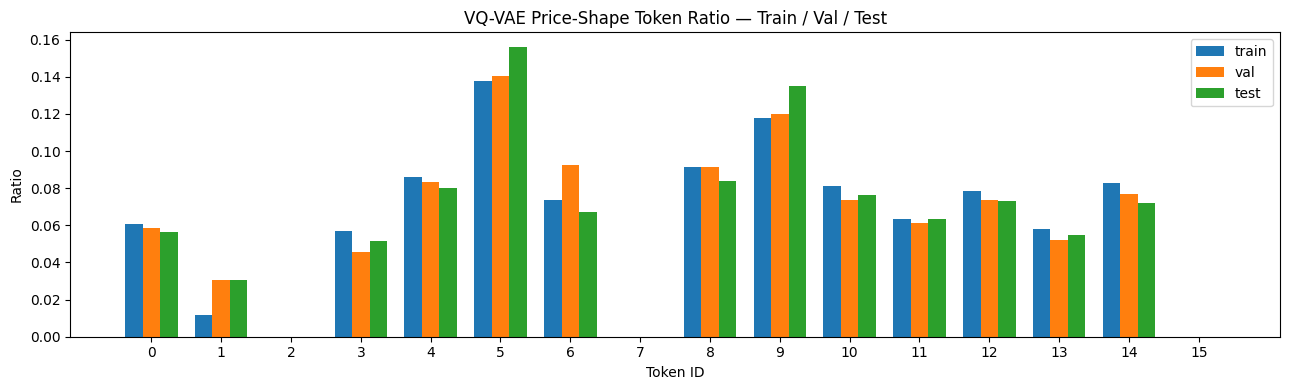

In [251]:
width = 0.25
x = np.arange(CODEBOOK_SIZE)

plt.figure(figsize=(13, 4))
plt.bar(x - width, tokens_to_ratios(train_tokens, k=CODEBOOK_SIZE), width=width, label="train")
plt.bar(x, tokens_to_ratios(val_tokens, k=CODEBOOK_SIZE), width=width, label="val")
plt.bar(x + width, tokens_to_ratios(test_tokens, k=CODEBOOK_SIZE), width=width, label="test")
plt.title("VQ-VAE Price-Shape Token Ratio — Train / Val / Test")
plt.xlabel("Token ID")
plt.ylabel("Ratio")
plt.xticks(all_token_ids)
plt.legend()
plt.tight_layout()
save_current_figure("01_global_token_ratio_histogram.png")
plt.show()


### 12.2 Per-symbol Token Heatmap

특정 token이 특정 symbol에만 과도하게 의존하는지 확인합니다. 행은 symbol, 열은 token이며 값은 symbol 내부 정규화 비율입니다.


saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a/price_shape_NASDAQ_1m_k16/figures/02_per_symbol_token_heatmap.png


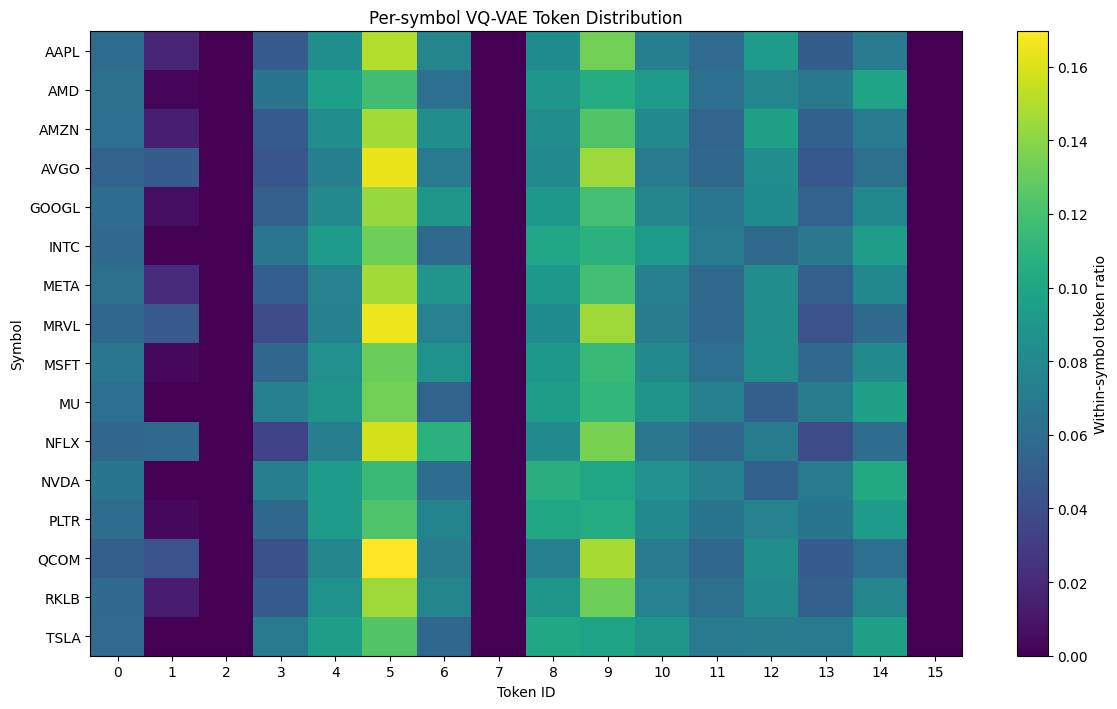

In [252]:
symbols_for_plot = sorted(per_symbol)
heatmap = np.zeros((len(symbols_for_plot), CODEBOOK_SIZE), dtype=float)

for row_index, symbol in enumerate(symbols_for_plot):
    symbol_tokens = tuple(per_symbol[symbol]["tokens"])
    counts = np.array(tokens_to_counts(symbol_tokens, k=CODEBOOK_SIZE), dtype=float)
    total = counts.sum()
    if total > 0:
        heatmap[row_index, :] = counts / total

plt.figure(figsize=(12, max(4, len(symbols_for_plot) * 0.45)))
plt.imshow(heatmap, aspect="auto", cmap="viridis")
plt.colorbar(label="Within-symbol token ratio")
plt.yticks(range(len(symbols_for_plot)), symbols_for_plot)
plt.xticks(range(CODEBOOK_SIZE), range(CODEBOOK_SIZE))
plt.title("Per-symbol VQ-VAE Token Distribution")
plt.xlabel("Token ID")
plt.ylabel("Symbol")
plt.tight_layout()
save_current_figure("02_per_symbol_token_heatmap.png")
plt.show()


### 12.3 Per-symbol Token Ratio Chart

heatmap은 전체 패턴을 보기 좋지만, token별 차이를 정량적으로 비교하기에는 막대그래프가 더 직관적입니다.

symbol 수가 많아도 읽기 쉽도록 token별 small multiple 형태로 표시합니다.


saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a/price_shape_NASDAQ_1m_k16/figures/03_per_symbol_token_ratio_chart.png


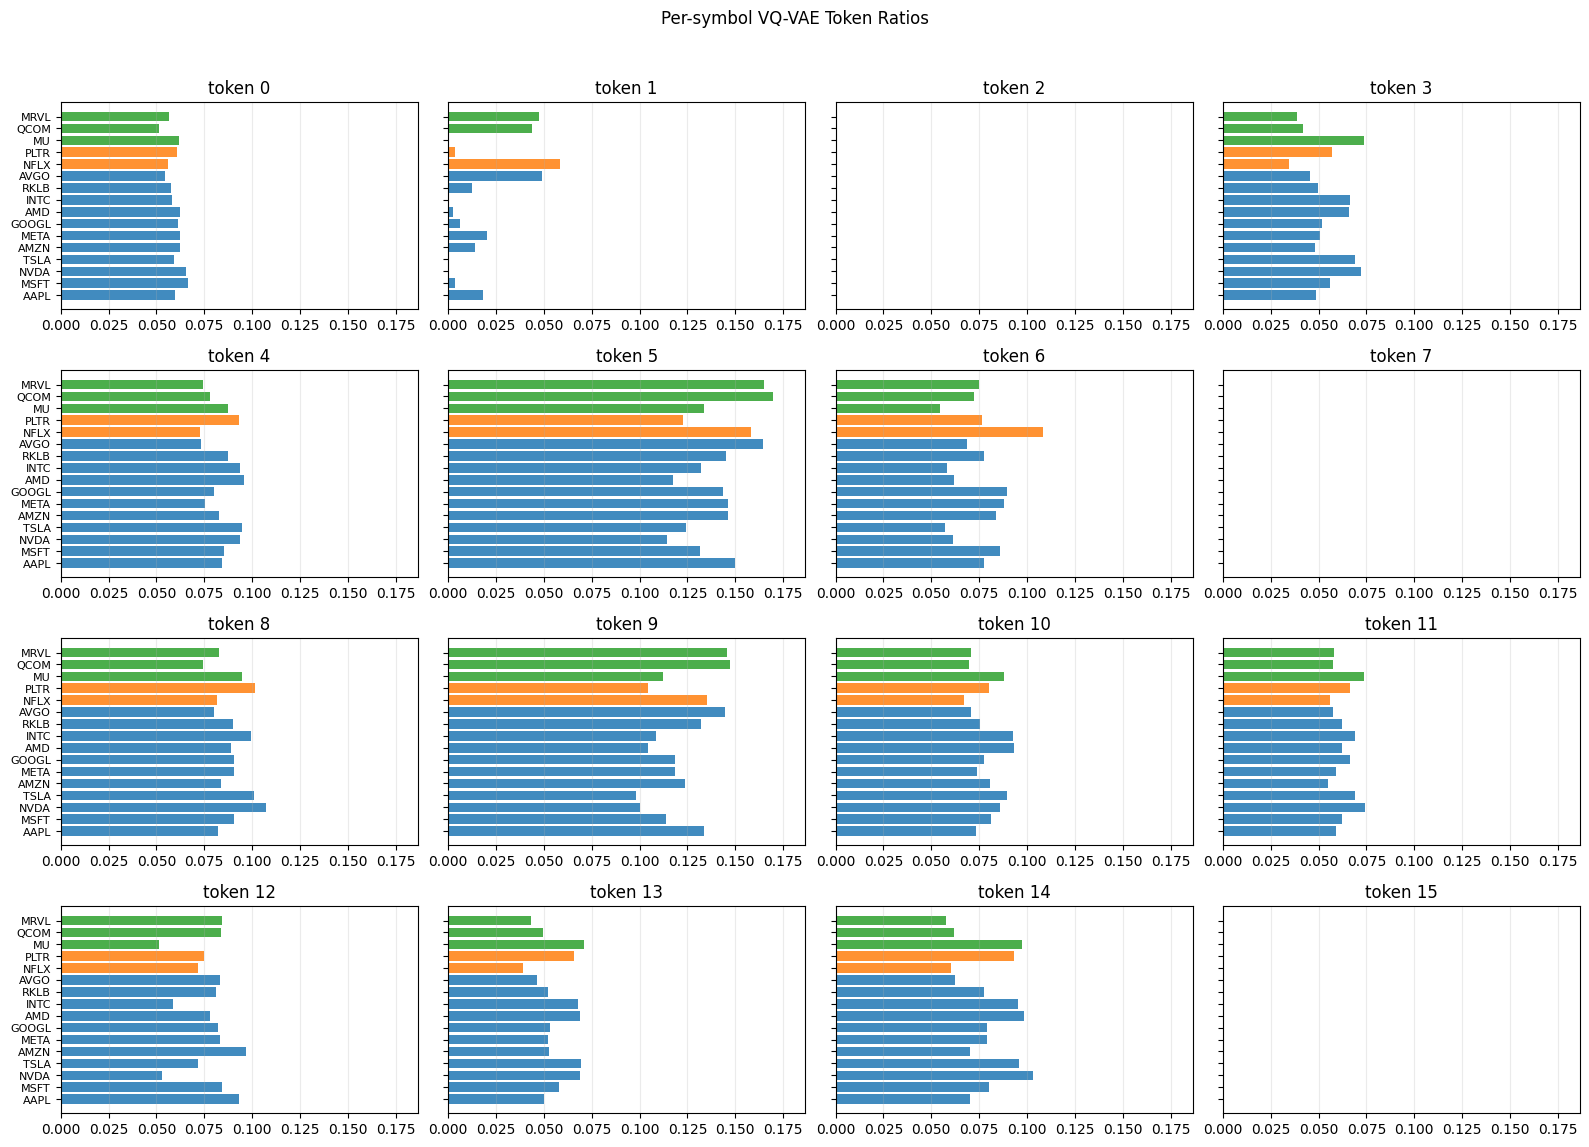

In [253]:
split_ordered_symbols = train_symbols + val_symbols + test_symbols
symbols_for_ratio_chart = [symbol for symbol in split_ordered_symbols if symbol in per_symbol]
ratio_matrix = np.array(
    [tokens_to_ratios(tuple(per_symbol[symbol]["tokens"]), k=CODEBOOK_SIZE) for symbol in symbols_for_ratio_chart],
    dtype=float,
)

cols = 4
rows = int(np.ceil(CODEBOOK_SIZE / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.0, rows * 2.8), sharey=True)
axes = np.array(axes).reshape(-1)
y = np.arange(len(symbols_for_ratio_chart))
colors = ["tab:blue" if s in train_symbols else "tab:orange" if s in val_symbols else "tab:green" for s in symbols_for_ratio_chart]

for token_id, ax in enumerate(axes[:CODEBOOK_SIZE]):
    values = ratio_matrix[:, token_id]
    ax.barh(y, values, color=colors, alpha=0.85)
    ax.set_title(f"token {token_id}")
    ax.set_xlim(0, max(0.01, float(ratio_matrix.max()) * 1.1))
    ax.grid(axis="x", alpha=0.25)
    ax.set_yticks(y)
    ax.set_yticklabels(symbols_for_ratio_chart, fontsize=8)

for ax in axes[CODEBOOK_SIZE:]:
    ax.axis("off")

fig.suptitle("Per-symbol VQ-VAE Token Ratios", y=1.02)
plt.tight_layout()
save_current_figure("03_per_symbol_token_ratio_chart.png")
plt.show()


### 12.4 Split-level Token Ratio Difference

held-out split의 token distribution이 train distribution과 얼마나 다른지 보기 위해 ratio 차이를 표시합니다.

```text
val ratio  - train ratio
test ratio - train ratio
```

0에 가까울수록 train과 held-out split의 token distribution이 유사합니다.


saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a/price_shape_NASDAQ_1m_k16/figures/04_split_token_ratio_difference.png


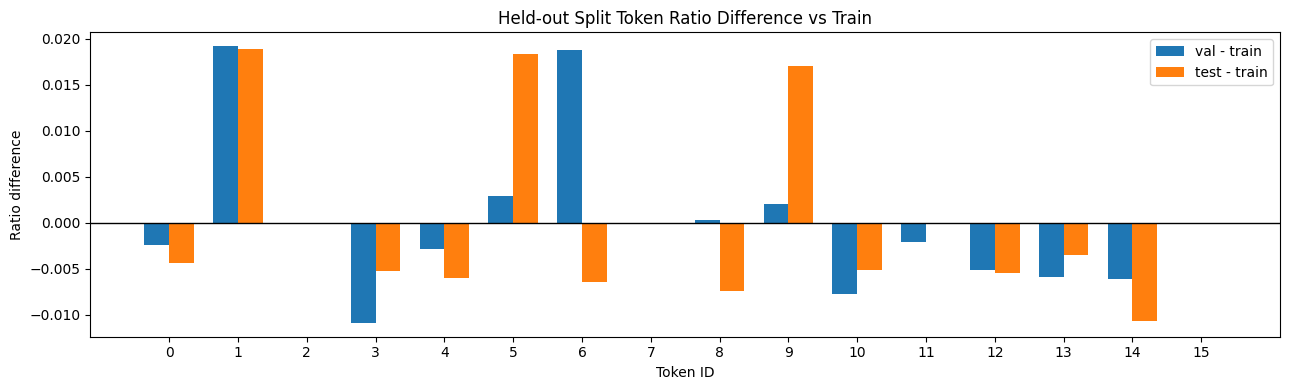

In [254]:
train_ratio = np.array(tokens_to_ratios(train_tokens, k=CODEBOOK_SIZE), dtype=float)
val_ratio = np.array(tokens_to_ratios(val_tokens, k=CODEBOOK_SIZE), dtype=float)
test_ratio = np.array(tokens_to_ratios(test_tokens, k=CODEBOOK_SIZE), dtype=float)

plt.figure(figsize=(13, 4))
plt.axhline(0.0, color="black", linewidth=1)
plt.bar(x - 0.18, val_ratio - train_ratio, width=0.36, label="val - train")
plt.bar(x + 0.18, test_ratio - train_ratio, width=0.36, label="test - train")
plt.title("Held-out Split Token Ratio Difference vs Train")
plt.xlabel("Token ID")
plt.ylabel("Ratio difference")
plt.xticks(range(CODEBOOK_SIZE), range(CODEBOOK_SIZE))
plt.legend()
plt.tight_layout()
save_current_figure("04_split_token_ratio_difference.png")
plt.show()


### 12.5 Mean Feature Heatmap by Token

token별 평균 4D price-shape feature vector를 확인합니다.


saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a/price_shape_NASDAQ_1m_k16/figures/05_mean_feature_heatmap.png


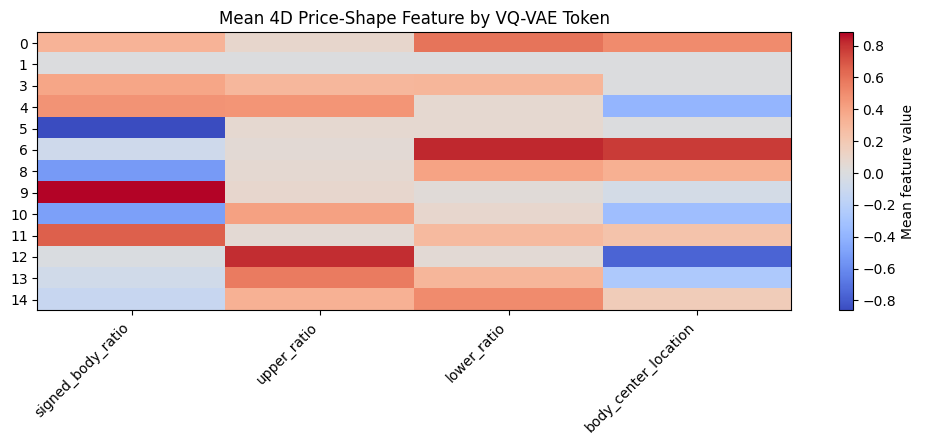

In [255]:
groups: dict[int, list[tuple[float, ...]]] = defaultdict(list)
for token, feature in zip(train_tokens, train_features, strict=True):
    groups[token].append(feature.as_tuple())

active_tokens = sorted(groups)
token_means = {token: np.mean(groups[token], axis=0) for token in active_tokens}
matrix = np.array([token_means[token] for token in active_tokens])

plt.figure(figsize=(10, max(4, len(active_tokens) * 0.35)))
plt.imshow(matrix, aspect="auto", cmap="coolwarm")
plt.colorbar(label="Mean feature value")
plt.yticks(range(len(active_tokens)), active_tokens)
plt.xticks(range(len(FEATURE_NAMES)), FEATURE_NAMES, rotation=45, ha="right")
plt.title("Mean 4D Price-Shape Feature by VQ-VAE Token")
plt.tight_layout()
save_current_figure("05_mean_feature_heatmap.png")
plt.show()


### 12.6 Prototype Candles

자주 등장한 token의 평균 price-shape를 candle glyph로 그립니다.


saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a/price_shape_NASDAQ_1m_k16/figures/06_prototype_candles.png


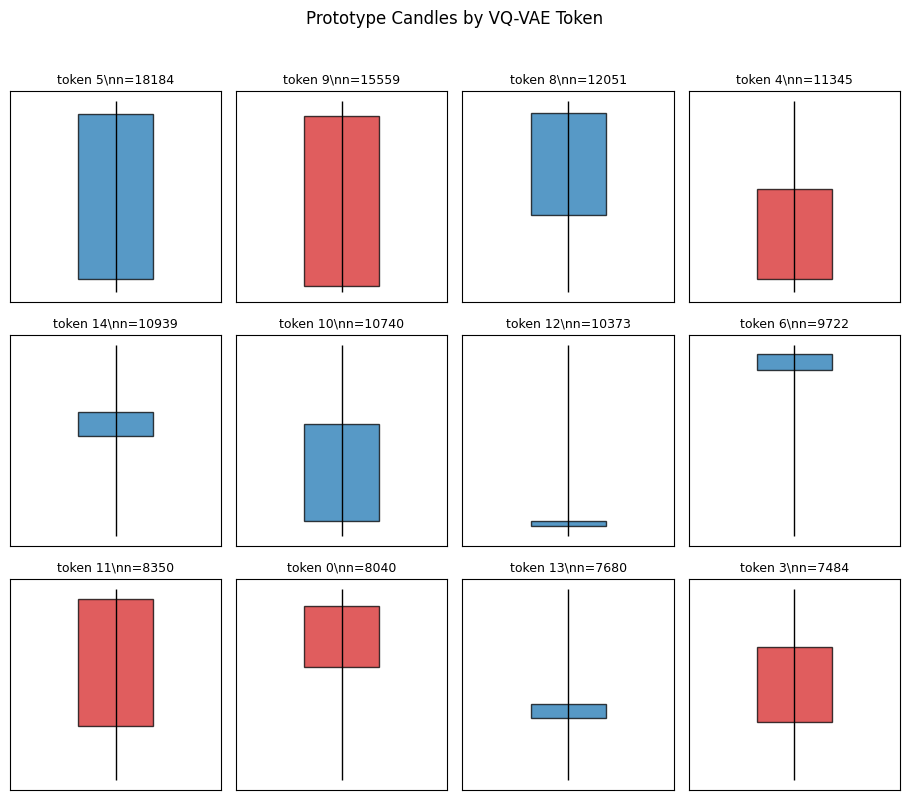

In [256]:
def draw_price_shape_prototype(ax, mean_feature, *, title: str) -> None:
    signed_body_ratio = float(mean_feature[0])
    upper_ratio = max(float(mean_feature[1]), 0.0)
    lower_ratio = max(float(mean_feature[2]), 0.0)
    body_ratio = abs(signed_body_ratio)
    direction_value = 1.0 if signed_body_ratio >= 0 else -1.0

    total = body_ratio + upper_ratio + lower_ratio
    if total <= 0:
        body_ratio = 0.02
        total = body_ratio

    body = body_ratio / total
    upper = upper_ratio / total
    lower = lower_ratio / total

    if direction_value >= 0:
        open_y = lower
        close_y = lower + body
        color = "tab:red"
    else:
        close_y = lower
        open_y = lower + body
        color = "tab:blue"

    low_y = 0.0
    high_y = lower + body + upper
    body_height = max(abs(close_y - open_y), 0.025)

    ax.vlines(0, low_y, high_y, color="black", linewidth=1)
    ax.add_patch(
        plt.Rectangle(
            (-0.16, min(open_y, close_y)),
            0.32,
            body_height,
            facecolor=color,
            edgecolor="black",
            alpha=0.75,
        )
    )
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-0.45, 0.45)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=9)


top_tokens = [token for token, _count in Counter(train_tokens).most_common(min(12, len(active_tokens)))]
cols = 4
rows = int(np.ceil(len(top_tokens) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.3, rows * 2.6))
axes = np.array(axes).reshape(-1)

for ax, token in zip(axes, top_tokens, strict=False):
    mean_feature = token_means[token]
    count = len(groups[token])
    draw_price_shape_prototype(ax, mean_feature, title=f"token {token}\\nn={count}")

for ax in axes[len(top_tokens):]:
    ax.axis("off")

fig.suptitle("Prototype Candles by VQ-VAE Token", y=1.02)
plt.tight_layout()
save_current_figure("06_prototype_candles.png")
plt.show()


### 12.7 Feature Scatter

가장 단순한 2D projection으로 token 분리가 눈에 보이는지 확인합니다.


saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a/price_shape_NASDAQ_1m_k16/figures/07_feature_scatter.png


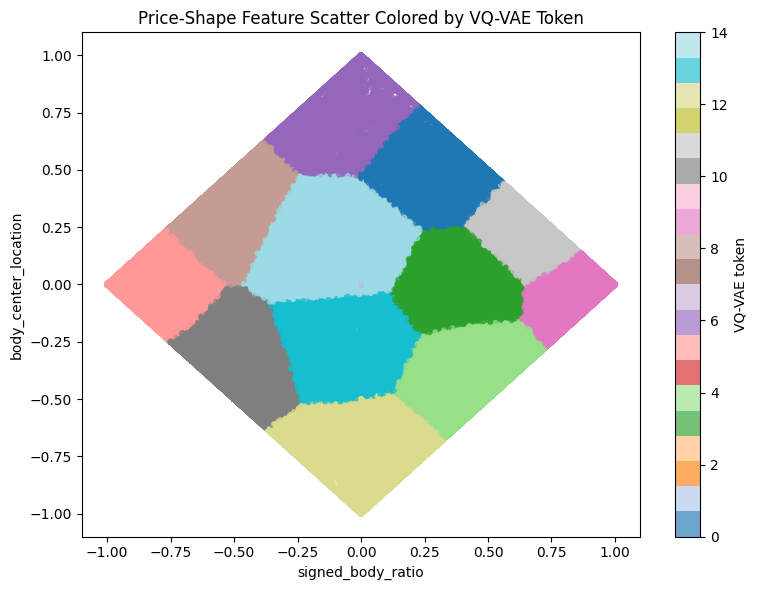

In [257]:
train_matrix = feature_matrix(train_features)

x_index = FEATURE_NAMES.index("signed_body_ratio")
y_index = FEATURE_NAMES.index("body_center_location")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    train_matrix[:, x_index],
    train_matrix[:, y_index],
    c=train_tokens,
    cmap="tab20",
    s=10,
    alpha=0.65,
)
plt.colorbar(scatter, label="VQ-VAE token")
plt.xlabel(FEATURE_NAMES[x_index])
plt.ylabel(FEATURE_NAMES[y_index])
plt.title("Price-Shape Feature Scatter Colored by VQ-VAE Token")
plt.tight_layout()
save_current_figure("07_feature_scatter.png")
plt.show()


### 12.8 VQ-VAE vs KMeans Distribution

동일한 codebook size에서 VQ-VAE token 분포와 KMeans cluster 분포를 비교합니다.


saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a/price_shape_NASDAQ_1m_k16/figures/08_vqvae_vs_kmeans_histogram.png


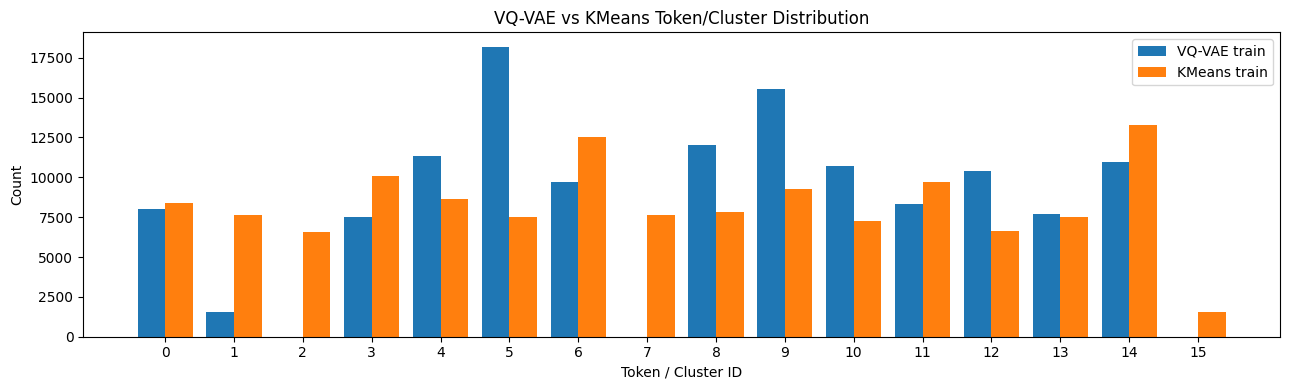

In [258]:
plt.figure(figsize=(13, 4))
plt.bar(
    x - 0.2,
    tokens_to_counts(train_tokens, k=CODEBOOK_SIZE),
    width=0.4,
    label="VQ-VAE train",
)
plt.bar(
    x + 0.2,
    tokens_to_counts(kmeans_train_tokens, k=CODEBOOK_SIZE),
    width=0.4,
    label="KMeans train",
)
plt.title("VQ-VAE vs KMeans Token/Cluster Distribution")
plt.xlabel("Token / Cluster ID")
plt.ylabel("Count")
plt.xticks(all_token_ids)
plt.legend()
plt.tight_layout()
save_current_figure("08_vqvae_vs_kmeans_histogram.png")
plt.show()


## 13. Deterministic Inference Check

같은 checkpoint와 같은 input이 같은 token sequence를 만드는지 확인합니다.


In [259]:
model_a = load_vqvae_model(result.checkpoint_path)
model_b = load_vqvae_model(result.checkpoint_path)

assert encode_features(model_a, train_features) == encode_features(model_b, train_features)
assert tuple(kmeans_model.predict(x_train).tolist()) == kmeans_train_tokens
print("deterministic inference: OK")


deterministic inference: OK


## 14. Interpretation Checklist

이 notebook 결과는 다음 순서로 해석합니다.

1. VQ-VAE가 train에서 token collapse 없이 여러 token을 사용하는가?
2. val/test held-out symbol에서도 token distribution이 크게 무너지지 않는가?
3. per-symbol heatmap에서 특정 token이 특정 symbol에만 과하게 의존하지 않는가?
4. token별 평균 feature와 prototype candle이 사람이 보기에도 다른 price-shape를 나타내는가?
5. KMeans baseline과 비교했을 때 VQ-VAE를 쓸 이유가 있는가?

가능한 주장:

```text
여러 종목에서 공유되는 price-shape token vocabulary 후보를 만들었다.
```

아직 하면 안 되는 주장:

```text
market state를 발견했다.
미래 수익률을 예측한다.
매매 신호를 만들었다.
```

다음 실험 후보:

```text
K = 8, 12, 16 비교 유지
more symbols 추가
1m vs 5m vs 1d 별도 실험
Phase 1B: shape + volatility/range scale
Phase 1C: shape + volume context
```
